# Model Setup and Loading

texto x

In [1]:
import sys

# Add project root in the path
sys.path.append('..')

In [2]:
from src.model_utils import load_model_and_tokenizer

model, tokenizer = load_model_and_tokenizer('gpt2')

d:\Deep Learning - Github\logit-lens-vs-tuned-lens\logit-lens-vs-tuned-lens\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 11381.89it/s]


# Data Extraction

textp x

In [3]:
import pandas as pd

# Load data
df_prompts = pd.read_csv('prompts_benchmark.txt', sep='\t')

df_prompts = df_prompts.sample(frac=1).reset_index(drop=True) # Disorganize data

df_prompts.head()

,category,prompt,target
0,common sense,"When you make a mistake with a pencil, you use an",eraser
1,logic,"Two, four, six, eight,",ten
2,grammar,We had already eaten dinner when they,arrived
3,grammar,Everyone in the room should do,their
4,common sense,"At a desk, you usually sit on a",chair


explicar que el benchmark el target no es exactamente la prediccion sino lo que se esperaria realmente, entonces se va a mirar cuantos targets coinciden con la prediccion real y crear un dataframe solo con estos

In [4]:
import torch

correct_predictions = 0
total_prompts = len(df_prompts)

model.eval() # Evaluation mode

correct_prompts = []

for index, row in df_prompts.iterrows():
    prompt = row['prompt']
    target = row['target']
    
    # Take tokenizer input
    inputs = tokenizer(prompt, return_tensors="pt")
    
    # Calculate output
    with torch.no_grad():
        outputs = model(**inputs)

    next_token_id = outputs.logits[0, -1, :].argmax(dim=-1).item()
    predicted_text = tokenizer.decode(next_token_id) # Get next word
    
    # Check if target matches with the prediction
    if predicted_text == target:
        correct_predictions += 1
        correct_prompts.append(row)
    
# Make new data frame
df_filtred = pd.DataFrame(correct_prompts).reset_index(drop=True)

print(f"Correct predictions: {correct_predictions} / {total_prompts}")

Correct predictions: 32 / 90


In [5]:
df_filtred.head()

,category,prompt,target
0,grammar,Everyone in the room should do,their
1,common sense,"At a desk, you usually sit on a",chair
2,logic,"A, B, C, D,",E
3,common sense,"At a restaurant, you choose your food from a",menu
4,common sense,"When you are very thirsty, you should",drink


# Loyalty Metrics

## Kullback-Leibler Divergence

explicar este metrica

In [12]:
from src.notebooks_utils import calculate_kl_divergence

from src.logit_lens import get_all_logit_lens_logits
from src.tuned_lens import get_all_tuned_lens_logits, SingleLayerTunedLens

import torch.nn as nn

num_layers = model.config.n_layer

# Total sum of kl divergence per layer
kl_div_sums_logit = {layer: 0.0 for layer in range(1, num_layers + 1)} 
kl_div_sums_tuned = {layer: 0.0 for layer in range(1, num_layers + 1)}

total_prompts = len(df_filtred)

# Import lenses

# Structure from lenses
hidden_size = model.config.n_embd
device = 'cpu'

lenses = nn.ModuleDict({
    str(layer_idx): SingleLayerTunedLens(hidden_size)
    for layer_idx in range(1, num_layers)
})

# Load weights saved
lenses.load_state_dict(torch.load('..\checkpoints/all_tuned_lenses.pt', map_location=device))
lenses.to(device)

lenses.eval()

# 
model.eval()
vocab_size = tokenizer.vocab_size

for index, row in df_filtred.iterrows():
    prompt = row['prompt']
    
    # Use function to get logits and final logits
    layer_logits_dict_logit = get_all_logit_lens_logits(model, tokenizer, prompt)
    layer_logits_dict_tuned = get_all_tuned_lens_logits(model, tokenizer, lenses, prompt)
    
    final_logits = layer_logits_dict_logit[num_layers]
    
    # Calculate kl div for each layer
    for layer_idx in range(1, num_layers + 1):
        layer_logits_logit = layer_logits_dict_logit[layer_idx]
        layer_logits_tuned = layer_logits_dict_tuned[layer_idx]
        
        # KL divergence for Logit Lens
        kl_val_logit = calculate_kl_divergence(layer_logits_logit.unsqueeze(0), final_logits.unsqueeze(0)) # Adjust the dimensions
        
        # KL divergence for Tuned Lens
        kl_val_tuned = calculate_kl_divergence(layer_logits_tuned.unsqueeze(0), final_logits.unsqueeze(0)) # Adjust the dimensions
        
        # Storage kl values
        kl_div_sums_logit[layer_idx] += kl_val_logit.item()
        kl_div_sums_tuned[layer_idx] += kl_val_tuned.item()
        
# Get average
kl_div_avg_logit = {layer: (kl_div_sums_logit[layer] / total_prompts) for layer in range(1, num_layers + 1)}
kl_div_avg_tuned = {layer: (kl_div_sums_tuned[layer] / total_prompts) for layer in range(1, num_layers + 1)}

C:\Users\Jako\AppData\Local\Temp\ipykernel_11764\2512387107.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lenses.load_state_dict(torch.load('..\checkpoints/all_tuned_

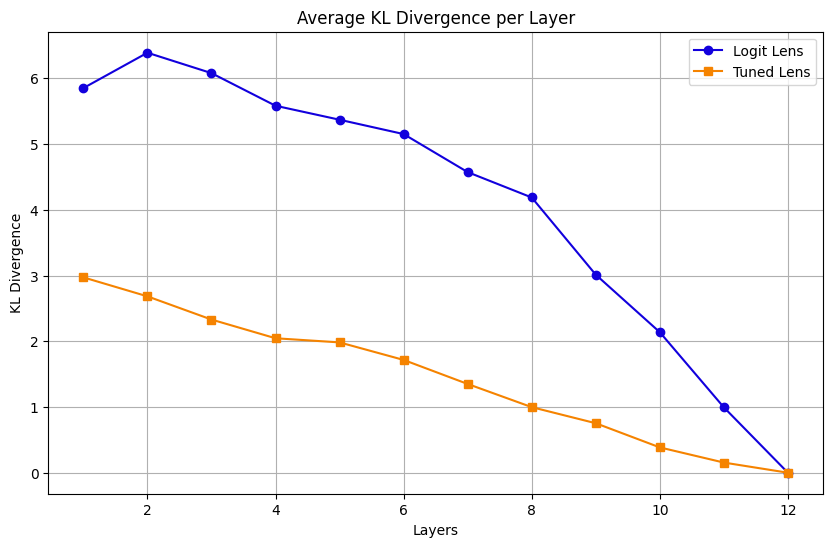

In [ ]:
import matplotlib.pyplot as plt

layers = list(kl_div_avg_logit.keys())
logit_values = list(kl_div_avg_logit.values())
tuned_values = list(kl_div_avg_tuned.values())

# Graph
plt.figure(figsize=(10, 6))

plt.plot(layers, logit_values, label='Logit Lens', marker='o', color="#1200ddff")
plt.plot(layers, tuned_values, label='Tuned Lens', marker='s', color="#f58300ff")

plt.title('Average KL Divergence per Layer')
plt.xlabel('Layers')
plt.ylabel('KL Divergence')

plt.grid()

plt.legend()
plt.show()

## Mean Reciprocal Rank

explicar tambien esta mierda

In [ ]:
from src.notebooks_utils import calculate_reciprocal_rank